In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()

(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


In [15]:
# Task 1 — Inspect & Handle Missing Values
# Print the shape of the DataFrame (number of rows and columns).
# Display the data types of all columns.
# Count the number of missing values in each column.
# Calculate the percentage of missing values for each column, rounded to 2 decimal places.
# Hint: Percentage = (missing count / total rows) * 100
print(f"Data shape: {df.shape}\n")
print(f"Data Type: {df.dtypes}\n")
print("Count of missing values")
missing_count=df.isnull().sum()
total_rows=df.shape[0]
print(missing_count)
print("Calculate the percentage of missing values")
percentage=(missing_count/total_rows)*100
print(percentage.round(2))

Data shape: (200, 6)

Data Type: order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object

Count of missing values
order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64
Calculate the percentage of missing values
order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


In [18]:
# Task 2 — Summarize & Visualize
# Use df.describe() to generate a summary of all numerical columns. In a markdown cell below the output, write two observations from the summary (for example: which column has the highest mean, or which column shows a large gap between its max and 75th percentile).
# Plot a histogram for the order_value column to visualize its distribution.
# Plot a box plot for the delivery_days column to inspect for outliers.
# Make sure every plot has a title and axis labels.
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

print(df.describe())

# Plot histogram for order_value
fig_hist = px.histogram(df, x='order_value', title='Histogram of Order Values')
fig_hist.update_layout(xaxis_title='Order Values', yaxis_title='Frequency')
fig_hist.show()

# Plot box plot for delivery_days
fig_box = px.box(df, y='delivery_days', title='Box Plot of Delivery Days')
fig_box.update_layout(yaxis_title='Delivery Days')
fig_box.show()

          order_id   order_value  delivery_days
count   200.000000    186.000000     190.000000
mean   1100.500000   3707.134409       7.810526
std      57.879185   9238.438378       4.075465
min    1001.000000    204.000000       1.000000
25%    1050.750000   1512.000000       4.000000
50%    1100.500000   2934.000000       8.000000
75%    1150.250000   3987.500000      12.000000
max    1200.000000  95000.000000      14.000000


From df.describe

 **Order Value Outliers:** The order_value column shows a significant difference between its 75th percentile 3987.5 and its maximum value 95000.0. This large gap suggests the presence of extreme outliers that are pulling up the maximum value considerably, which is also reflected in its high standard deviation 9238.44 relative to its mean 3707.13.
  **Delivery Days Distribution:** The delivery_days column has a mean 7.81 very close to its 50th percentile median, 8.0, and its 25th 4.0 and 75th 12.0 percentiles are quite symmetrical around the median. This indicates a relatively balanced distribution without extreme skewness or major outliers, further supported by its small standard deviation 4.08 compared to its range 1 to 14.

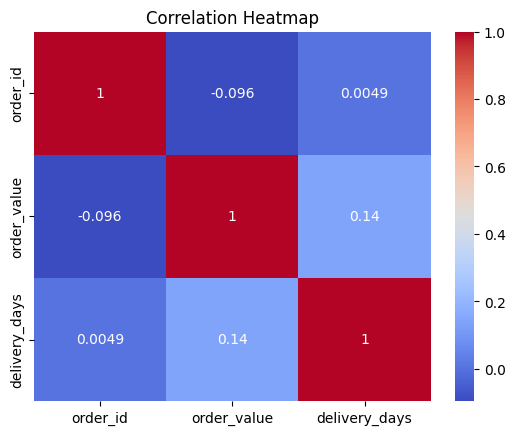

In [23]:
# Task 3 — Correlation Analysis
# Compute the correlation matrix for all numerical columns using df.corr().
# Plot a heatmap of the correlation matrix with annotation values visible inside each cell.
# In a markdown cell, write one observation from the heatmap — identify any two columns that appear to have a notable positive or negative relationship.
import seaborn as sns
import matplotlib.pyplot as plt
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Observation from the Correlation Heatmap

Order Value and Delivery Days There appears to be a slight positive correlation between order_value and delivery_days correlation coefficient of approximately 0.14.

This suggests that as the value of an order increases, there might be a very minor tendency for the delivery days to also slightly increase, although the relationship is not strong.